In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from time import perf_counter
import math

In [2]:
# Implement baseline algorithm
def baseline_max_sublist(arr: list[int]) -> int:
    max_sum = -math.inf

    for i in range(len(arr)):
        current_sum = 0
        for j in range(i, len(arr)):
            current_sum += arr[j]
            if current_sum > max_sum:
                max_sum = current_sum

    return max_sum

In [3]:
# Implement target algorithm
def kadane_max_sublist(arr: list[int]) -> int:
    max_so_far = -math.inf
    current_max = 0
    for i in range(len(arr)):
        current_max += arr[i]
        if current_max > max_so_far:
            max_so_far = current_max
        if current_max < 0:
            current_max = 0
    return max_so_far


In [4]:
def generate_lists_by_size(sizes: list[int]) -> list[list[int]]:
    return [np.random.randint(-100, 101, size=s).tolist() for s in sizes]

In [ ]:
size_sample = [100, 500, 1000, 2500, 5000, 10000]
test_lists = generate_lists_by_size(size_sample)
print(f"Generated {len(test_lists)} lists with sizes: {size_sample}")
print(f"Example list (n={size_sample[0]}): {test_lists[0][:10]}...")


Generated 7 lists with sizes: [100, 500, 1000, 2500, 5000, 10000, 1000000]
Example list (n=100): [-1, -49, -89, 31, -63, 20, 37, -42, 62, -43]...


In [ ]:
NUM_RUNS = 5
baseline_times = []

for size in size_sample:
    run_times = []
    for _ in range(NUM_RUNS):
        test_arr = np.random.randint(-100, 101, size=size).tolist()
        start = perf_counter()
        baseline_max_sublist(test_arr)
        run_times.append(perf_counter() - start)
    avg_time = sum(run_times) / NUM_RUNS
    baseline_times.append(avg_time)
    print(f"Baseline (n={size}): avg time over {NUM_RUNS} runs = {avg_time:.6f}s")

Baseline (n=100): avg time over 5 runs = 0.000580s
Baseline (n=500): avg time over 5 runs = 0.013509s
Baseline (n=1000): avg time over 5 runs = 0.028825s
Baseline (n=2500): avg time over 5 runs = 0.178528s
Baseline (n=5000): avg time over 5 runs = 0.716299s
Baseline (n=10000): avg time over 5 runs = 2.895225s


In [7]:
kadane_times = []

for size in size_sample:
    run_times = []
    for _ in range(NUM_RUNS):
        test_arr = np.random.randint(-100, 101, size=size).tolist()
        start = perf_counter()
        kadane_max_sublist(test_arr)
        run_times.append(perf_counter() - start)
    avg_time = sum(run_times) / NUM_RUNS
    kadane_times.append(avg_time)
    print(f"Kadane (n={size}): avg time over {NUM_RUNS} runs = {avg_time:.6f}s")

Kadane (n=100): avg time over 5 runs = 0.000014s
Kadane (n=500): avg time over 5 runs = 0.000051s
Kadane (n=1000): avg time over 5 runs = 0.000285s
Kadane (n=2500): avg time over 5 runs = 0.000267s
Kadane (n=5000): avg time over 5 runs = 0.000533s
Kadane (n=10000): avg time over 5 runs = 0.002278s


   Array Size  Baseline (s)  Kadane (s)
0         100      0.000785    0.000014
1         500      0.013037    0.000051
2        1000      0.027279    0.000285
3        2500      0.171515    0.000267
4        5000      0.709616    0.000533
5       10000      2.768232    0.002278


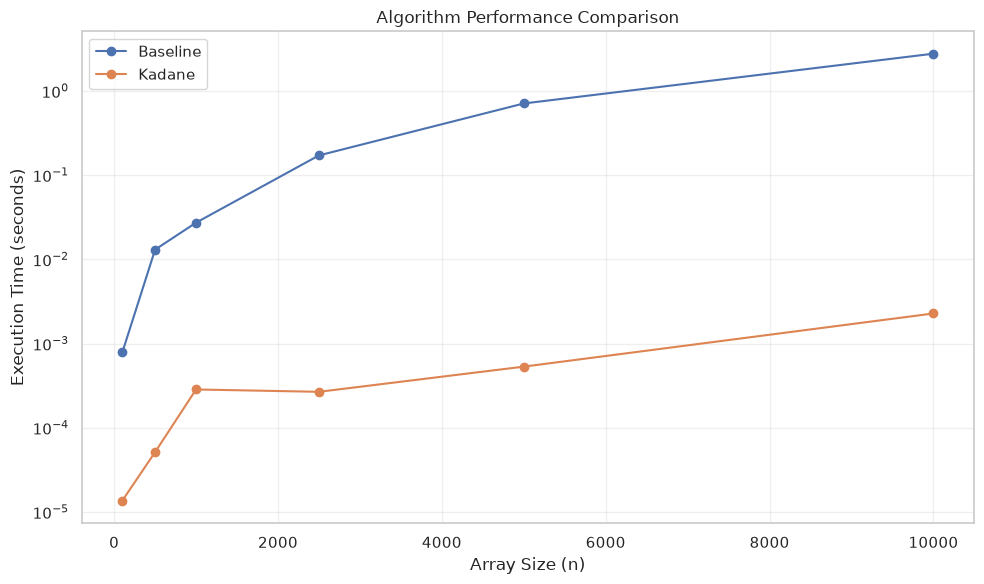

In [9]:
results = pd.DataFrame({
    "Array Size": size_sample,
    "Baseline (s)": baseline_times,
    "Kadane (s)": kadane_times,
})
print(results)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
plt.plot(size_sample, baseline_times, marker="o", label="Baseline")
plt.plot(size_sample, kadane_times, marker="o", label="Kadane")
plt.xlabel("Array Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Algorithm Performance Comparison")
plt.yscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()